# Evaluate models


In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.rename(columns={"MedHouseVal": "target"})



In [3]:

df.shape


(20640, 9)

In [4]:
X = df.drop(columns="target")   # the 8 features the model learns from
y = df["target"]                # the house price it must predict
print(X.shape, y.shape)


(20640, 8) (20640,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)


(16512, 8) (4128, 8)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [7]:
pd.Series(model.coef_, index=X.columns).sort_values()


Longitude    -0.433708
Latitude     -0.419792
AveRooms     -0.123323
AveOccup     -0.003526
Population   -0.000002
HouseAge      0.009724
MedInc        0.448675
AveBedrms     0.783145
dtype: float64

In [8]:
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.3f}")
print(f"R2:   {r2:.3f}")


RMSE: 0.746
R2:   0.576


In [9]:
pd.DataFrame({"actual": y_test.values[:10], "predicted": y_pred[:10]})


,actual,predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [10]:
print("y_test length:", len(y_test))
print("y_pred length:", len(y_pred))

print("Actual first 10:", len(y_test[:10]))
print("Predicted first 10:", len(y_pred[:10]))

y_test length: 4128
y_pred length: 4128
Actual first 10: 10
Predicted first 10: 10


In [11]:

# Generate predictions for the entire test dataset
y_pred = model.predict(X_test)

# Check the number of predictions
print("Actual values:", len(y_test))
print("Predicted values:", len(y_pred))

Actual values: 4128
Predicted values: 4128


In [12]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.5332001304956555


In [13]:

# Import the R² function
from sklearn.metrics import  r2_score

# Calculate R² using actual and predicted values
r2 =  r2_score(y_test, y_pred)

# Display the result
print("R² Score:", r2)


R² Score: 0.575787706032451


In [14]:
print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae)

print("R²:", r2)

Linear Regression Results
-------------------------
MAE: 0.5332001304956555
R²: 0.575787706032451


In [15]:

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)


Mean Squared Error: 0.5558915986952442


In [16]:
print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

Linear Regression Results
-------------------------
MAE: 0.5332001304956555
MSE: 0.5558915986952442
R²: 0.575787706032451


In [17]:
import sys
print(sys.executable)

c:\Users\kahal\Documents\ml\ml-prediction-api\venv\Scripts\python.exe


In [4]:
from sklearn.model_selection import train_test_split

In [8]:

from sklearn.datasets import fetch_california_housing

# Load the dataset as a pandas DataFrame
housing = fetch_california_housing(as_frame=True)

# Get the complete dataset
df = housing.frame

# Display the first 5 rows
print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [9]:

# X = input features used to make predictions
X = df.drop(columns=["MedHouseVal"])

# y = target value we want to predict
y = df["MedHouseVal"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20640, 8)
y shape: (20640,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Input features
    y,                  # Target values
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42     # Reproducible split
)

In [12]:

# Step 1: Import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

# Step 2: Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Step 3: Train the model
rf_model.fit(X_train, y_train)

# Step 4: Generate predictions
rf_pred = rf_model.predict(X_test)

# Step 5: Check the number of predictions
print("Number of predictions:", len(rf_pred))


Number of predictions: 4128


In [13]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)


Random Forest Results
---------------------
MAE: 0.32754256845930246
MSE: 0.2553684927247781
R² Score: 0.8051230593157366


In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

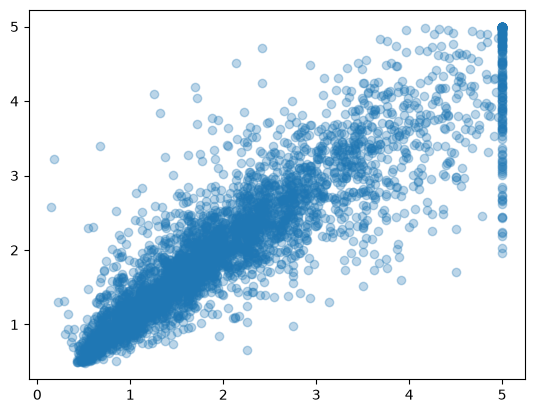

In [16]:
plt.scatter(y_test, rf_pred, alpha=0.3)

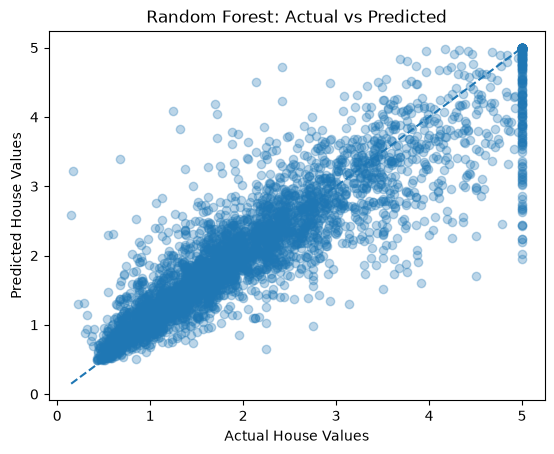

In [18]:


plt.scatter(y_test, rf_pred, alpha=0.3)


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

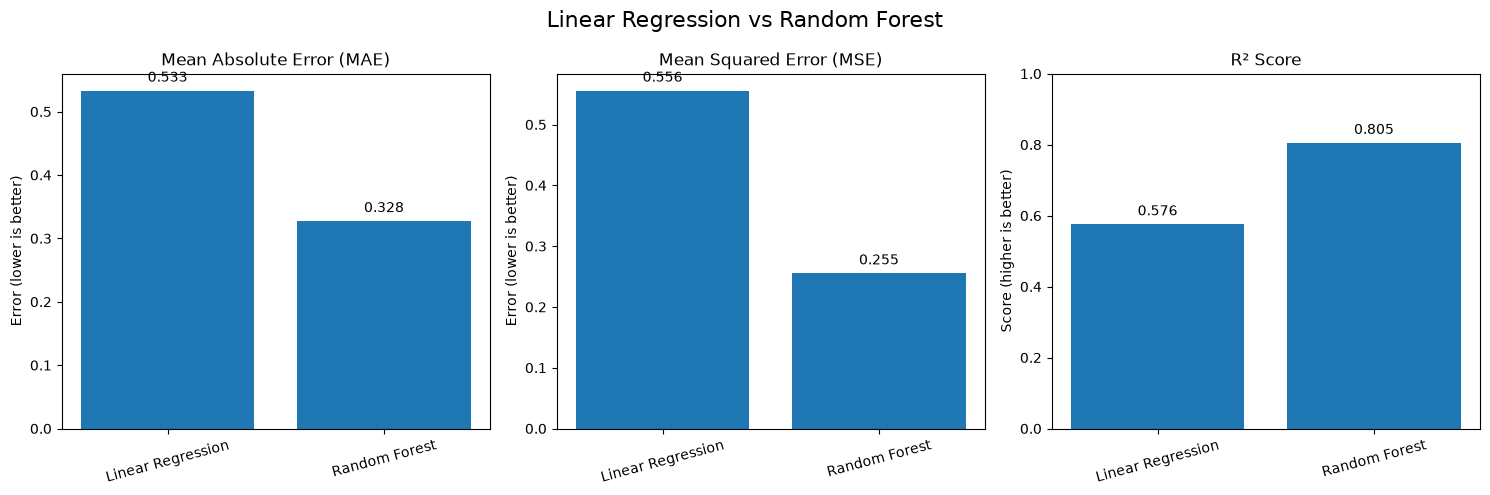

In [19]:

import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ["Linear Regression", "Random Forest"]

# Evaluation results from your models
mae = [0.5332, 0.3275]
mse = [0.5559, 0.2554]
r2 = [0.5758, 0.8051]

# Create three comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: MAE
axes[0].bar(models, mae)
axes[0].set_title("Mean Absolute Error (MAE)")
axes[0].set_ylabel("Error (lower is better)")
axes[0].tick_params(axis="x", rotation=15)

# Plot 2: MSE
axes[1].bar(models, mse)
axes[1].set_title("Mean Squared Error (MSE)")
axes[1].set_ylabel("Error (lower is better)")
axes[1].tick_params(axis="x", rotation=15)

# Plot 3: R² Score
axes[2].bar(models, r2)
axes[2].set_title("R² Score")
axes[2].set_ylabel("Score (higher is better)")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=15)

# Add values above each bar
for ax in axes:
    for bar in ax.patches:
        ax.annotate(
            f"{bar.get_height():.3f}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points"
        )

plt.suptitle("Linear Regression vs Random Forest", fontsize=16)
plt.tight_layout()
plt.show()
